In [1]:
import pandas as pd
import numpy as np
import re
import string

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [26]:

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import pickle

pickle.dump(best_model, open("model.pkl", "wb"))
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))

In [27]:
df = pd.read_csv("email_spam.csv", encoding='latin-1')


In [5]:
df = df[['v1', 'v2']]
df.columns = ['label', 'text']

In [6]:
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

In [7]:
df.head()

,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [22]:
df.tail()

,label,text,clean_text
5567,1,This is the 2nd time we have tried 2 contact u...,2nd time tried 2 contact u u å£750 pound prize...
5568,0,Will Ì_ b going to esplanade fr home?,ì b going esplanade fr home
5569,0,"Pity, * was in mood for that. So...any other s...",pity mood soany suggestion
5570,0,The guy did some bitching but I acted like i'd...,guy bitching acted like id interested buying s...
5571,0,Rofl. Its true to its name,rofl true name


In [8]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()


In [9]:
def preprocess(text):
    text = text.lower()
   
    text = re.sub(r'http\S+|www\S+', ' URL ', text)
    
    
    text = re.sub(r'\S+@\S+', ' EMAIL ', text)
    
   
    text = text.translate(str.maketrans('', '', string.punctuation))
   
    words = text.split()
    
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    
    return " ".join(words)

In [10]:
df['clean_text'] = df['text'].apply(preprocess)

In [11]:
# TF-IDF
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X = vectorizer.fit_transform(df['clean_text'])

In [12]:

y = df['label']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC()
}

In [15]:

results = {}

In [16]:
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    
    print(f"\n{name}")
    print("Accuracy:", acc)
    print(classification_report(y_test, preds))


Naive Bayes
Accuracy: 0.9739910313901345
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       965
           1       1.00      0.81      0.89       150

    accuracy                           0.97      1115
   macro avg       0.99      0.90      0.94      1115
weighted avg       0.97      0.97      0.97      1115


Logistic Regression
Accuracy: 0.9506726457399103
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       965
           1       0.99      0.64      0.78       150

    accuracy                           0.95      1115
   macro avg       0.97      0.82      0.87      1115
weighted avg       0.95      0.95      0.95      1115


SVM
Accuracy: 0.9739910313901345
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       965
           1       0.99      0.81      0.89       150

    accuracy                           0.97      1115
  

In [17]:
best_model = LogisticRegression(max_iter=1000)
best_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


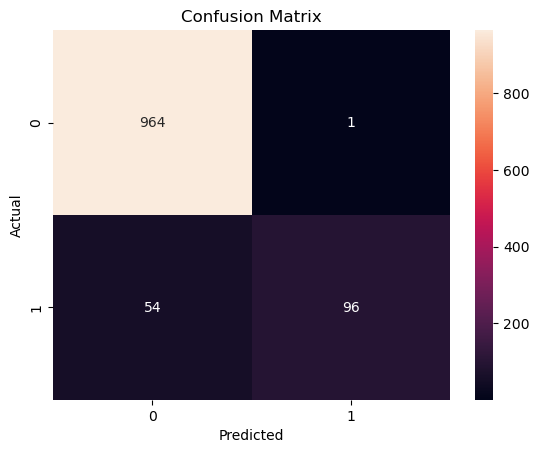

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

preds = best_model.predict(X_test)

cm = confusion_matrix(y_test, preds)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [19]:
pickle.dump(best_model, open("model.pkl", "wb"))
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))

In [20]:
def predict_email(text):
    text = preprocess(text)
    vector = vectorizer.transform([text])
    prediction = best_model.predict(vector)[0]
    
    return "Spam" if prediction == 1 else "Not Spam"

In [21]:
print(predict_email("Congratulations! You won a free lottery ticket"))
print(predict_email("Hey, are we meeting tomorrow?"))

Not Spam
Not Spam


In [23]:
print(predict_email("Will Ì_ b going to esplanade fr home?"))

Not Spam


In [24]:
print(predict_email("Free entry in 2 a wkly comp to win FA Cup fina..."))

Spam
